## **Data Wrangling**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import requests
from io import BytesIO
import plotly.express as px
import matplotlib.ticker as mtick

### Gathering Data
Menentukan dataset yang relevan dari hasil sintesis data, selanjutnya untuk memastikan kualitas data sebelum dilakukan proces assessing dan cleaning untuk memastikan kualitas data sebelum digunakan pada tahap AI modeling

In [2]:
 # Gathering Data
url = "https://raw.githubusercontent.com/Capstone-Project-Coding-Camp-2026/Data-Scientist/main/dataset_fix.zip"
resp = requests.get(url)
zip_file = zipfile.ZipFile(BytesIO(resp.content))

with zip_file.open('dataset_a_nlp.csv') as f:
    df_a = pd.read_csv(f)

with zip_file.open('dataset_b_forecasting.csv') as f:
    df_b = pd.read_csv(f)

with zip_file.open('dataset_c_whatif (1).csv') as f:
    df_c = pd.read_csv(f)

In [3]:
# Tabel df_a
df_a.head()

,description,category,source_bank,transaction_type
0,PYMNT NETFLIX.COM,hiburan,BSI,debit
1,PYMNT GOFOOD,makanan,BNI,debit
2,DB EDC HAPPY PUPPY KTV,hiburan,BRI,debit
3,QRIS PMT FOTOKOPI PRINT DPS,lainnya,Danamon,debit
4,TRSF E-BANKING DB GRABFOOD,makanan,Danamon,debit


**Dataset A: NLP Classifier**

Dataset ini berisi data transaksi keuangan yang digunakan untuk melakukan klasifikasi kategori transaksi. Berikut penjelasan tiap kolom:

1. description (string)

Kolom ini berisi teks deskripsi transaksi dari mutasi rekening dan merupakan input utama untuk model machine learning.
Berisi informasi seperti nama merchant, jenis transaksi, atau layanan. Format bervariasi tergantung bank/e-wallet.

2. category (string)

Kolom ini adalah label target yang ingin diprediksi oleh model. Berisi kategori transaksi (total 13 kelas). Digunakan sebagai output dalam proses klasifikasi.

3. source_bank (string) (opsional)

Menunjukkan asal bank atau e-wallet dari transaksi.Bisa membantu model mengenali pola tertentu dari tiap platform. Tidak wajib digunakan, tetapi dapat meningkatkan performa model

4. transaction_type (string) (opsional)

Menunjukkan jenis transaksi yang dilakukan. Memberikan konteks tambahan terkait aktivitas transaksi. Dapat digunakan sebagai fitur tambahan dalam model


In [4]:
# Tabel df_b
df_b.head()

,user_id,persona_id,bulan,bulan_index,monthly_income,expense_housing,expense_food,expense_transport,expense_entertainment,expense_health,expense_education,expense_debt_payment,total_expense,savings_capacity,current_total_balance,expense_to_income_ratio,savings_rate
0,USR_00000,6,2024-01,1,6136600.0,1099900.0,1852500.0,631300.0,328500.0,306300.0,661800.0,729600.0,5609900.0,526700.0,17245400.0,0.9142,0.0858
1,USR_00000,6,2024-02,2,6053100.0,1100900.0,1668600.0,600700.0,310900.0,307500.0,466800.0,737600.0,5193000.0,860100.0,18105500.0,0.8579,0.1421
2,USR_00000,6,2024-03,3,6062500.0,1107200.0,1870800.0,650800.0,321400.0,307500.0,467000.0,736100.0,5460800.0,601700.0,18707200.0,0.9008,0.0992
3,USR_00000,6,2024-04,4,12408900.0,1103300.0,2212700.0,680700.0,300800.0,308800.0,456100.0,735500.0,5797900.0,6611000.0,25318200.0,0.4672,0.5328
4,USR_00000,6,2024-05,5,5855800.0,1107500.0,1767400.0,597700.0,324400.0,310900.0,506900.0,737600.0,5352400.0,503400.0,25821600.0,0.9140,0.0860


**Dataset B: Time-Series Forecasting**

Dataset ini berisi data keuangan bulanan user selama 24 bulan, mencakup pendapatan (monthly_income) dan berbagai jenis pengeluaran (expense_*). Setiap user memiliki identitas tetap, sementara nilai keuangan berubah tiap bulan mengikuti pola tertentu (misalnya kenaikan saat Ramadhan atau mudik).

Tujuan dataset ini adalah untuk memprediksi total pengeluaran (total_expense) serta menganalisis perilaku finansial user, seperti pola pengeluaran, kemampuan menabung, dan rasio keuangan.

In [5]:
# Tabel df_c
df_c.head()

,persona_id,age,employment_type,city_tier,total_income,monthly_expenses,expense_to_income_ratio,monthly_cashflow,savings_rate,current_savings,...,paylater_usage_history,financial_literacy_score,impulse_spending_tendency,item_price,available_cash,paylater_interest_rate,paylater_tenor_months,paylater_monthly_burden,item_to_income_ratio,label_whatif
0,4,24,entrepreneur,tier_1,20374000.0,15705000.0,0.7708,4669000.0,0.2292,37082000.0,...,never,0.48,high,2699000.0,3392000.0,0.027,24,0.0057,0.1325,just_buy
1,1,24,permanent,tier_3,5035000.0,3042000.0,0.6042,1993000.0,0.3958,196000.0,...,occasional,0.25,high,1504000.0,2965000.0,0.034,12,0.0257,0.2987,just_buy
2,9,45,gig,tier_1,3241000.0,1981000.0,0.6112,1260000.0,0.3888,125000.0,...,never,0.48,low,751000.0,2737000.0,0.028,24,0.0099,0.2317,just_buy
3,8,18,entrepreneur,tier_1,9377000.0,5298000.0,0.5650,4079000.0,0.4350,26282000.0,...,frequent,0.19,medium,9959000.0,8406000.0,0.021,3,0.3615,1.0621,dont_buy
4,8,24,not_working,tier_1,2119000.0,1166000.0,0.5503,953000.0,0.4497,2028000.0,...,occasional,0.07,low,1263000.0,2173000.0,0.018,24,0.0253,0.5960,just_buy


**Dataset C: What-If Classification**

Dataset ini berisi profil keuangan, utang, dan perilaku user, serta skenario pembelian barang. Data mencakup kondisi finansial saat ini (income, expenses, savings), profil utang (KPR, pinjol, kartu kredit), hingga faktor perilaku seperti literasi keuangan dan impulsive spending.

Tujuan dataset ini adalah untuk memprediksi keputusan finansial (label_whatif), yaitu apakah user sebaiknya:

* just_buy: aman untuk beli
* buy_careful: perlu pertimbangan
* dont_buy: tidak disarankan

Prediksi didasarkan pada kemampuan bayar, rasio keuangan, dan risiko utang, sehingga dapat digunakan untuk analisis kelayakan pembelian atau sistem rekomendasi finansial.

### Assessing Data
Tahap assessing dilakukan untuk memastikan data sintesis memiliki struktur yang konsisten, tidak mengandung missing values berlebih, serta sesuai dengan kebutuhan model AI.

In [6]:
# Menilai data df_a
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6300 entries, 0 to 6299
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   description       6300 non-null   object
 1   category          6300 non-null   object
 2   source_bank       6300 non-null   object
 3   transaction_type  6300 non-null   object
dtypes: object(4)
memory usage: 197.0+ KB


In [7]:
# Menilai data df_b
df_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240000 entries, 0 to 239999
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  240000 non-null  object 
 1   persona_id               240000 non-null  int64  
 2   bulan                    240000 non-null  object 
 3   bulan_index              240000 non-null  int64  
 4   monthly_income           240000 non-null  float64
 5   expense_housing          240000 non-null  float64
 6   expense_food             240000 non-null  float64
 7   expense_transport        240000 non-null  float64
 8   expense_entertainment    240000 non-null  float64
 9   expense_health           240000 non-null  float64
 10  expense_education        240000 non-null  float64
 11  expense_debt_payment     240000 non-null  float64
 12  total_expense            240000 non-null  float64
 13  savings_capacity         240000 non-null  float64
 14  curr

In [8]:
# Menilai data df_c
df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   persona_id                 10000 non-null  int64  
 1   age                        10000 non-null  int64  
 2   employment_type            10000 non-null  object 
 3   city_tier                  10000 non-null  object 
 4   total_income               10000 non-null  float64
 5   monthly_expenses           10000 non-null  float64
 6   expense_to_income_ratio    10000 non-null  float64
 7   monthly_cashflow           10000 non-null  float64
 8   savings_rate               10000 non-null  float64
 9   current_savings            10000 non-null  float64
 10  has_emergency_fund         10000 non-null  int64  
 11  emergency_fund_months      10000 non-null  float64
 12  has_kpr                    10000 non-null  int64  
 13  has_vehicle_credit         10000 non-null  int6

In [9]:
# Missing value df_a
df_a.isna().sum()

,0
description,0
category,0
source_bank,0
transaction_type,0


In [10]:
# Missing value df_b
df_b.isna().sum()

,0
user_id,0
persona_id,0
bulan,0
bulan_index,0
monthly_income,0
expense_housing,0
expense_food,0
expense_transport,0
expense_entertainment,0
expense_health,0


In [11]:
# Missing value df_c
df_c.isna().sum()

,0
persona_id,0
age,0
employment_type,0
city_tier,0
total_income,0
monthly_expenses,0
expense_to_income_ratio,0
monthly_cashflow,0
savings_rate,0
current_savings,0


In [12]:
# Duplikasi df_a
print("Jumlah duplikasi: ",df_a.duplicated().sum())

Jumlah duplikasi:  747


In [13]:
# Duplikasi df_b
print("Jumlah duplikasi: ",df_b.duplicated().sum())

Jumlah duplikasi:  0


In [14]:
# Duplikasi df_c
print("Jumlah duplikasi: ",df_c.duplicated().sum())

Jumlah duplikasi:  0


### **Cleaning Data**
Tahap cleaning data dilakukan dengan melakukan standarisasi format data, konversi tipe data datetime, serta preprocessing tambahan untuk memastikan dataset siap digunakan pada tahap analisis dan modeling.

1. **Data Duplikat**

Pada Dataset A ditemukan adanya data duplikat. Namun, proses penghapusan duplikat **tidak dilakukan** karena data tersebut masih dianggap wajar dan merepresentasikan transaksi yang dapat terjadi berulang dalam kondisi nyata.

2. **Konversi Tipe Data**

Konversi tipe data dilakukan untuk memastikan seluruh variabel memiliki format yang sesuai, sehingga data siap digunakan dalam proses analisis dan pemodelan

In [15]:
# Konversi bulan ke datetime
try:
    df_b['bulan_dt'] = pd.to_datetime(df_b['bulan'])
    print("\n[KONVERSI TANGGAL]")
    print(f"'bulan' berhasil dikonversi ke datetime")
except:
    print("Format 'bulan' tidak standar, menggunakan 'bulan_index' sebagai referensi")
    df_b['bulan_dt'] = pd.to_datetime('2024-01-01') + pd.to_timedelta(df_b['bulan_index'] - 1, unit='M')


[KONVERSI TANGGAL]
'bulan' berhasil dikonversi ke datetime


## Exploratory Data Analysis (EDA)


In [16]:
# Parameter statistik df_a
df_a.describe()

,description,category,source_bank,transaction_type
count,6300,6300,6300,6300
unique,4329,13,13,3
top,DB FLAZZ TOPUP,makanan,BRI,debit
freq,34,800,979,4800


In [17]:
# Parameter statistik df_b
df_b.describe()

,persona_id,bulan_index,monthly_income,expense_housing,expense_food,expense_transport,expense_entertainment,expense_health,expense_education,expense_debt_payment,total_expense,savings_capacity,current_total_balance,expense_to_income_ratio,savings_rate,bulan_dt
count,240000.000000,240000.000000,2.400000e+05,2.400000e+05,2.400000e+05,2.400000e+05,2.400000e+05,2.400000e+05,2.400000e+05,2.400000e+05,2.400000e+05,2.400000e+05,2.400000e+05,240000.000000,240000.000000,240000
mean,8.745400,12.500000,7.798388e+06,1.352520e+06,1.842691e+06,7.520734e+05,7.360078e+05,3.108457e+05,3.227764e+05,6.926163e+05,6.009531e+06,1.788857e+06,3.546245e+07,0.851557,0.148443,2024-12-15 22:00:00.000000768
min,1.000000,1.000000,7.708000e+05,2.125000e+05,9.420000e+04,0.000000e+00,2.750000e+04,2.370000e+04,0.000000e+00,0.000000e+00,8.798000e+05,-8.989900e+06,0.000000e+00,0.284500,-2.243500,2024-01-01 00:00:00
25%,4.000000,6.750000,3.395200e+06,7.622000e+05,1.200975e+06,4.071000e+05,2.342750e+05,1.237000e+05,1.247000e+05,0.000000e+00,3.155100e+06,3.970000e+04,4.813825e+06,0.719300,0.011200,2024-06-23 12:00:00
50%,9.000000,12.500000,5.516750e+06,1.207200e+06,1.647600e+06,6.237000e+05,4.622000e+05,2.192000e+05,2.123000e+05,2.859000e+05,4.951100e+06,6.193000e+05,1.427690e+07,0.860800,0.139200,2024-12-16 12:00:00
75%,13.000000,18.250000,8.419425e+06,1.586600e+06,2.174000e+06,8.570000e+05,7.095250e+05,3.664000e+05,4.730000e+05,8.769000e+05,6.771825e+06,1.978900e+06,4.264585e+07,0.988800,0.280700,2025-06-08 12:00:00
max,18.000000,24.000000,6.203980e+07,5.900300e+06,9.816600e+06,5.094900e+06,1.033200e+07,4.952900e+06,1.971000e+06,4.802500e+06,3.779550e+07,3.878960e+07,5.052764e+08,3.243500,0.715500,2025-12-01 00:00:00
std,5.223705,6.922201,7.180959e+06,8.503127e+05,1.062685e+06,5.723753e+05,1.074230e+06,3.049438e+05,2.831644e+05,9.931719e+05,4.666451e+06,3.711733e+06,5.354347e+07,0.208354,0.208354,NaN


In [18]:
# Parameter statistik df_c
df_c.describe()

,persona_id,age,total_income,monthly_expenses,expense_to_income_ratio,monthly_cashflow,savings_rate,current_savings,has_emergency_fund,emergency_fund_months,...,total_debt,debt_to_income_ratio,credit_card_utilization,financial_literacy_score,item_price,available_cash,paylater_interest_rate,paylater_tenor_months,paylater_monthly_burden,item_to_income_ratio
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.000000,...,1.000000e+04,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000
mean,9.527300,31.517000,5.851242e+06,4.144554e+06,0.696838,1.706689e+06,0.303162,1.669999e+07,0.374000,2.985900,...,4.551648e+07,1.151365,0.306339,0.438991,2.943930e+06,2.988709e+06,0.025147,11.366700,0.080164,0.502978
std,5.176015,8.076115,4.115927e+06,3.142110e+06,0.115990,1.342240e+06,0.115990,2.435676e+07,0.483888,2.948072,...,1.098107e+08,4.545688,0.178913,0.177560,4.150297e+06,2.837350e+06,0.005780,8.095702,0.113250,0.495957
min,1.000000,18.000000,3.010000e+05,1.520000e+05,0.449900,5.000000e+04,0.079800,1.000000e+03,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.010000,5.000000e+04,5.600000e+04,0.015000,3.000000,0.000800,0.019800
25%,5.000000,25.000000,2.813500e+06,1.886750e+06,0.602875,7.410000e+05,0.205700,2.752750e+06,0.000000,0.900000,...,0.000000e+00,0.000000,0.170000,0.310000,5.440000e+05,1.038750e+06,0.020000,6.000000,0.014600,0.147600
50%,10.000000,32.000000,5.069000e+06,3.423500e+06,0.698650,1.364500e+06,0.301350,8.331500e+06,0.000000,2.100000,...,0.000000e+00,0.000000,0.280000,0.430000,1.537000e+06,2.132500e+06,0.025000,12.000000,0.037800,0.350950
75%,14.000000,39.000000,7.743000e+06,5.524000e+06,0.794300,2.304250e+06,0.397125,2.056175e+07,1.000000,4.100000,...,1.519025e+07,0.285325,0.420000,0.560000,3.640000e+06,4.004000e+06,0.030000,24.000000,0.099600,0.694000
max,18.000000,45.000000,2.487000e+07,2.266300e+07,0.920200,1.090500e+07,0.550100,4.728950e+08,1.000000,27.000000,...,5.738810e+08,126.884000,1.000000,1.000000,5.727000e+07,3.121900e+07,0.035000,24.000000,1.701700,5.000000


### Dataset A

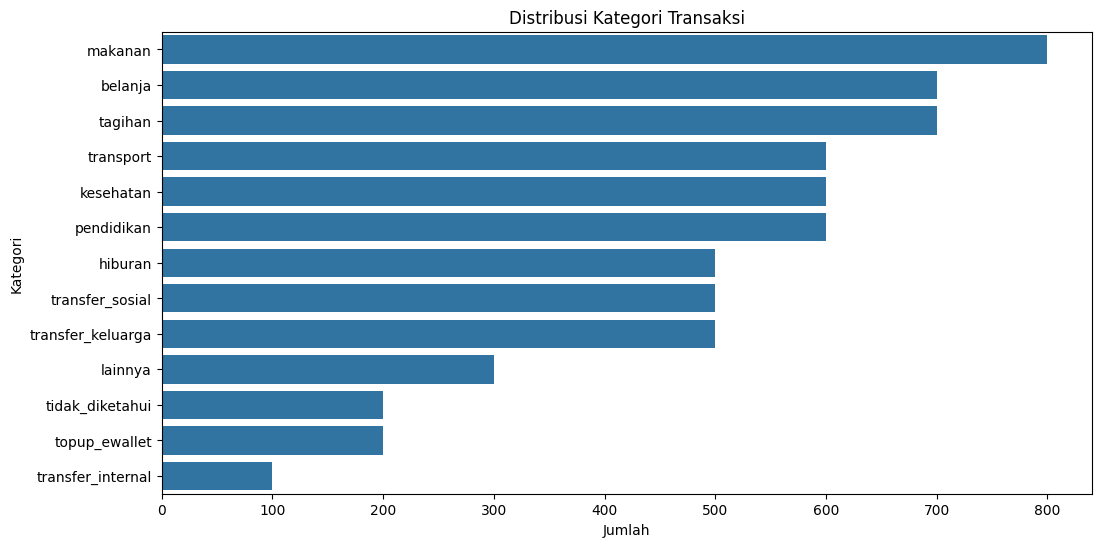

In [19]:
# Visualisasi distribusi kategori transaksi
plt.figure(figsize=(12,6))

sns.countplot(
    y=df_a['category'],
    order=df_a['category'].value_counts().index
)

plt.title('Distribusi Kategori Transaksi')
plt.xlabel('Jumlah')
plt.ylabel('Kategori')

plt.show()

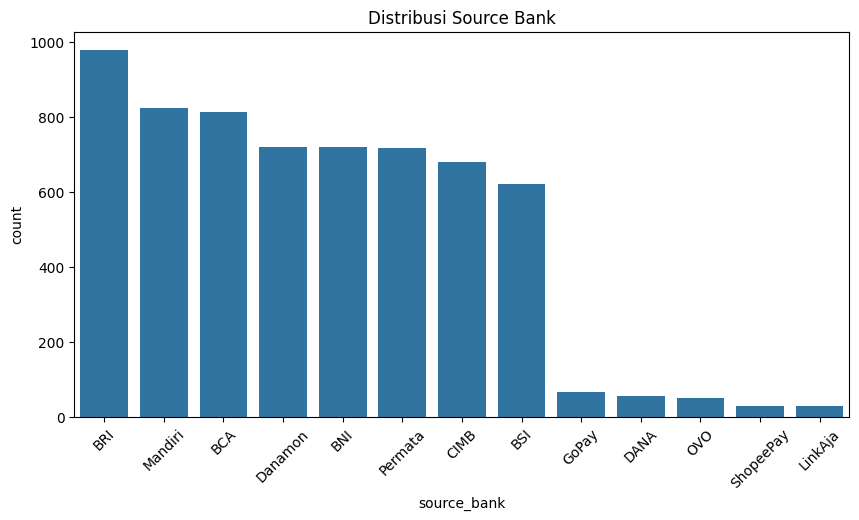

In [20]:
# Distribusi sumber bank dari transaksi
plt.figure(figsize=(10,5))

sns.countplot(
    x=df_a['source_bank'],
    order=df_a['source_bank'].value_counts().index
)

plt.title('Distribusi Source Bank')
plt.xticks(rotation=45)

plt.show()

In [21]:
# Menghitung jumlah transaksi berdasarkan jenisnya
category_counts = df_a['category'].value_counts()

print(category_counts)

category
makanan              800
belanja              700
tagihan              700
transport            600
kesehatan            600
pendidikan           600
hiburan              500
transfer_sosial      500
transfer_keluarga    500
lainnya              300
tidak_diketahui      200
topup_ewallet        200
transfer_internal    100
Name: count, dtype: int64


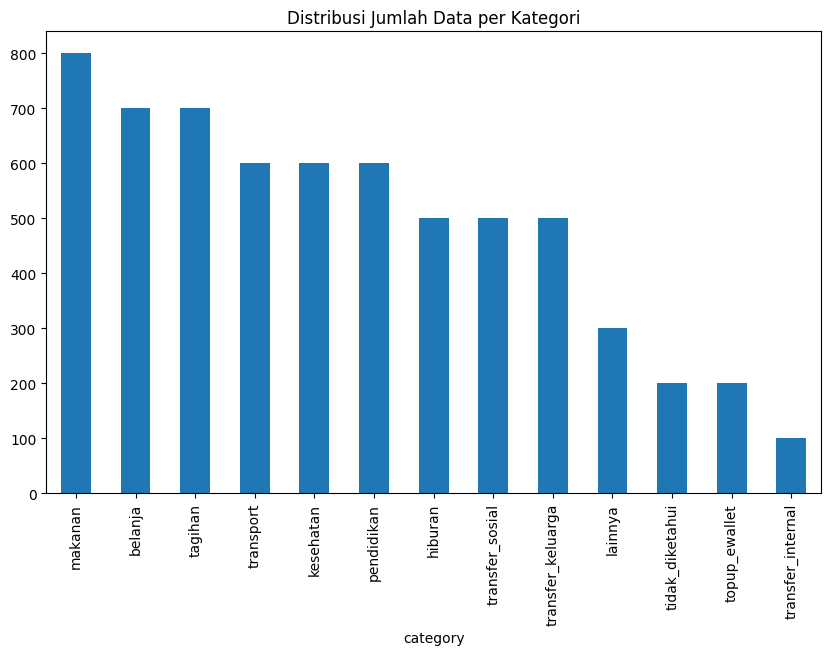

In [22]:
# Distribusi jumlah data transaksi per kategori
plt.figure(figsize=(10,6))

category_counts.plot(
    kind='bar'
)

plt.title('Distribusi Jumlah Data per Kategori')

plt.show()

### Insight Dataset A

1. Dataset didominasi oleh kategori makanan, belanja, tagihan yang memiliki jumlah data relatif seimbang sesuai proses sintesis dataset.

2. Mayoritas transaksi berasal dari bank seperti BRI, Mandiri, BCA.

3. Sebagian besar kategori memiliki distribusi yang seimbang, meskipun beberapa kategori seperti transfer_internal memiliki jumlah data lebih sedikit dibanding kategori utama.

### Dataset B

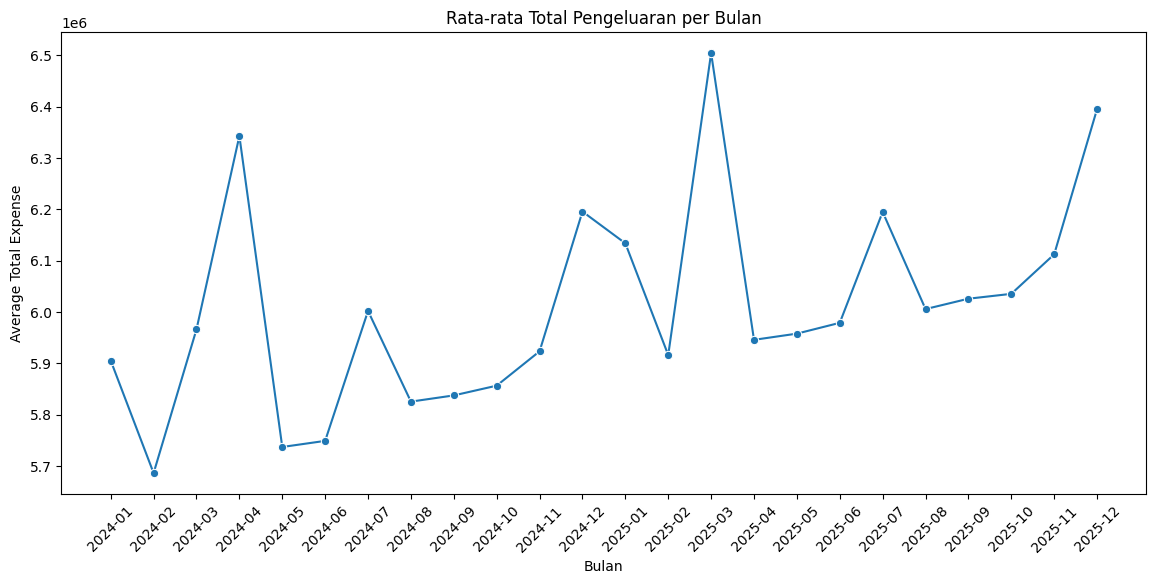

In [23]:
# Rata-rata pengeluaran pengguna tiap bulannya
import matplotlib.pyplot as plt
import seaborn as sns

monthly_expense = (
    df_b.groupby('bulan')['total_expense']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    x='bulan',
    y='total_expense',
    data=monthly_expense,
    marker='o'
)

plt.title('Rata-rata Total Pengeluaran per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Average Total Expense')

plt.xticks(rotation=45)

plt.show()

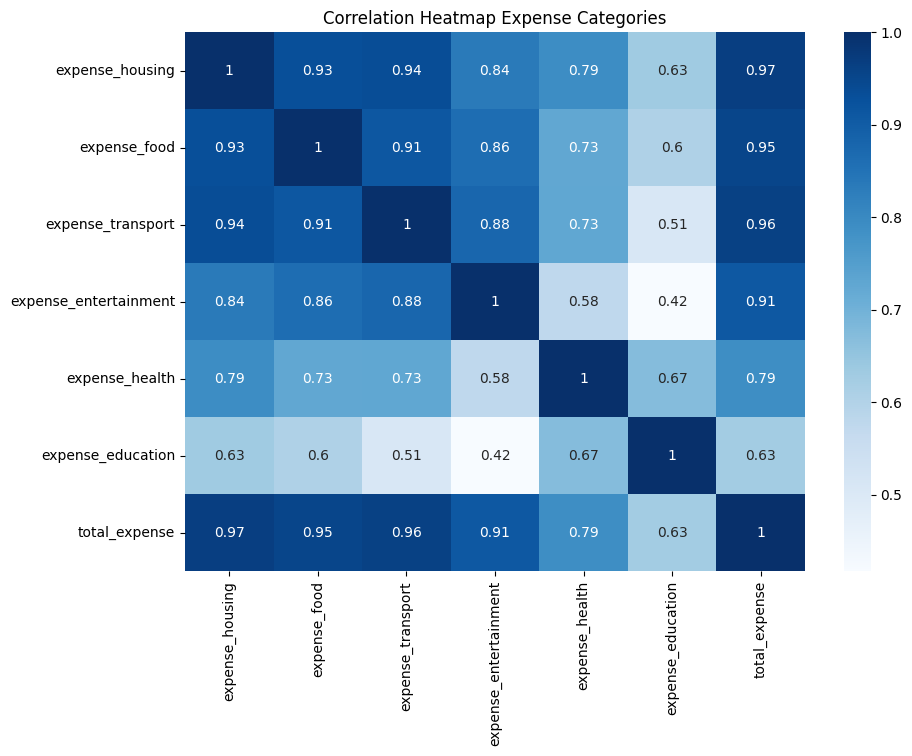

In [24]:
# Kategori pengeluaran yang paling memengaruhi total expense
expense_cols = [
    'expense_housing',
    'expense_food',
    'expense_transport',
    'expense_entertainment',
    'expense_health',
    'expense_education'
]

correlation = df_b[expense_cols + ['total_expense']].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap Expense Categories')

plt.show()

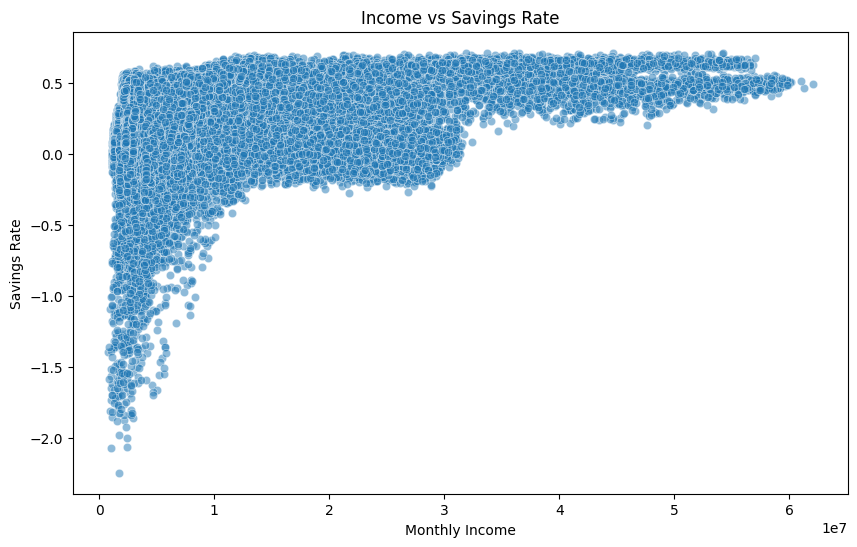

In [25]:
# Hubungan antara income dan saving rate
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='monthly_income',
    y='savings_rate',
    data=df_b,
    alpha=0.5
)

plt.title('Income vs Savings Rate')
plt.xlabel('Monthly Income')
plt.ylabel('Savings Rate')

plt.show()

In [26]:
# Rata rata expense tiap persona per bulannya
persona_trend = (
    df_b.groupby(['persona_id', 'bulan'])['total_expense']
    .mean()
    .reset_index()
)

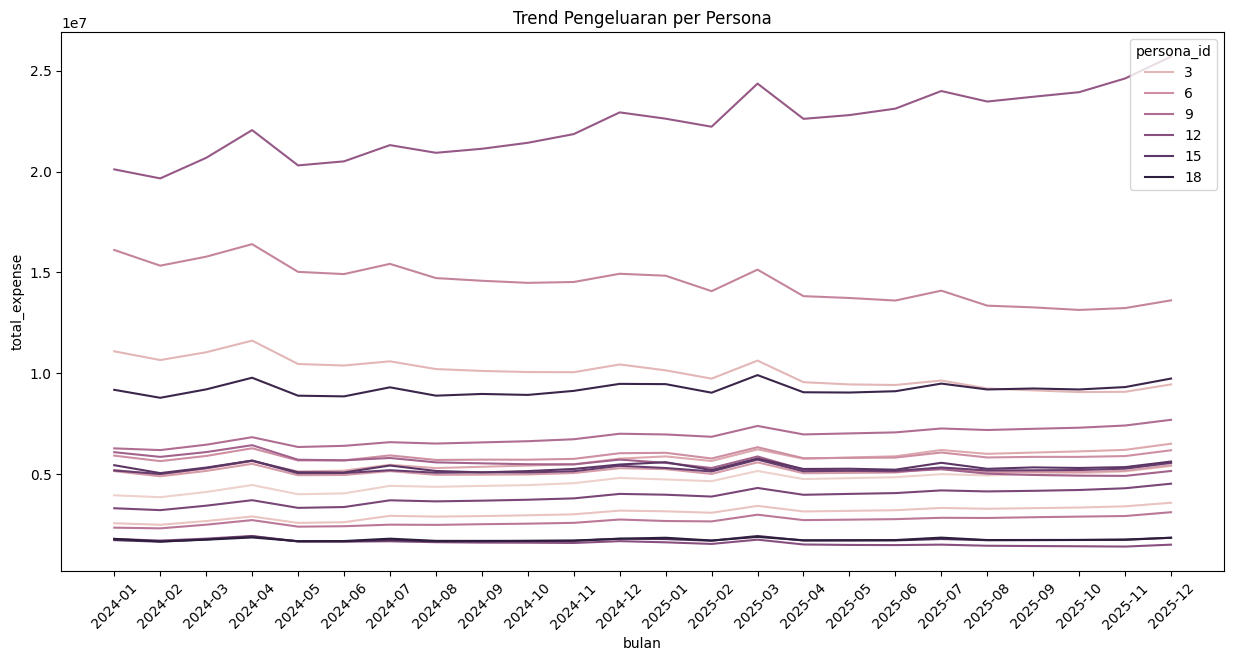

In [27]:
# Visualisasi tren finansial tiap persona
plt.figure(figsize=(15,7))

sns.lineplot(
    x='bulan',
    y='total_expense',
    hue='persona_id',
    data=persona_trend
)

plt.title('Trend Pengeluaran per Persona')
plt.xticks(rotation=45)

plt.show()

### Insight Dataset B

1. Rata-rata pengeluaran pengguna menunjukkan pola fluktuatif sepanjang waktu dengan peningkatan pada periode tertentu seperti pada bulan Februari 2024 ke April 2024, yang mengindikasikan adanya seasonal spending pattern.

2. Kategori yang memiliki korelasi yang kuat dengan total_expense adalah Hosuing, Transport, dan Food. Disisi lain yang paling rendah ialah education.

3. Hubungan antara pendapatan dan tingkat tabungan adalah positif namun melandai. Pendapatan yang lebih tinggi meningkatkan kemampuan untuk menabung secara signifikan pada awalnya, tetapi setelah kebutuhan dasar terpenuhi, faktor perilaku dan gaya hidup menciptakan batas atas (ceiling) di mana persentase tabungan tidak lagi meningkat secara drastis meskipun pendapatan terus naik.

4. Persona yang memiliki tren finansial paling memburuk secara signifikan adalah Persona 12 (garis paling atas dengan warna ungu tua).

- Kenaikan Pengeluaran yang Drastis: Di awal tahun 2024, pengeluarannya berada di angka 20 juta. Namun, di akhir 2025, angka ini melonjak hingga menyentuh 25 juta. Artinya, ada kenaikan biaya hidup sebesar 25% dalam waktu dua tahun.

- Ketidakstabilan (Volatilitas): Dibandingkan persona lain yang garisnya cenderung lurus/datar, Persona 12 memiliki lonjakan (peak) dan penurunan yang sangat tajam. Ini menunjukkan gaya hidup yang kurang terkontrol atau banyaknya pengeluaran mendadak yang besar.

- Tren Akhir Tahun yang Mengkhawatirkan: Perhatikan sisi kanan grafik (akhir 2025). Saat persona lain mulai landai atau bahkan turun, Persona 12 justru sedang dalam posisi menanjak tajam tanpa tanda-tanda akan turun.


### Dataset C

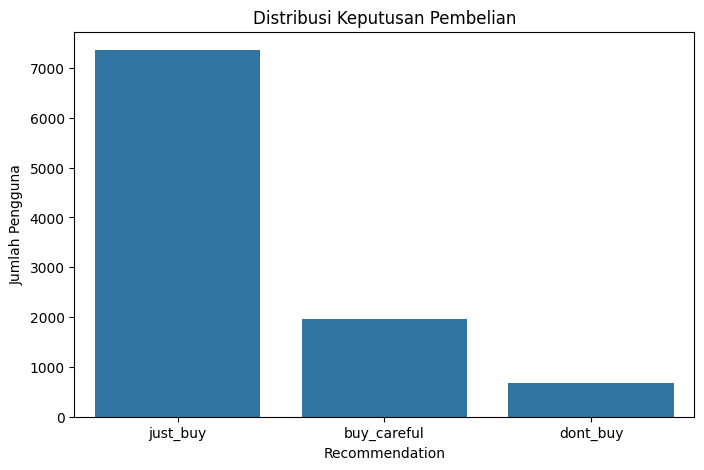

In [28]:
# Distribusi keputusan pembelian pengguna
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='label_whatif',
    data=df_c,
    order=df_c['label_whatif'].value_counts().index
)

plt.title('Distribusi Keputusan Pembelian')
plt.xlabel('Recommendation')
plt.ylabel('Jumlah Pengguna')

plt.show()

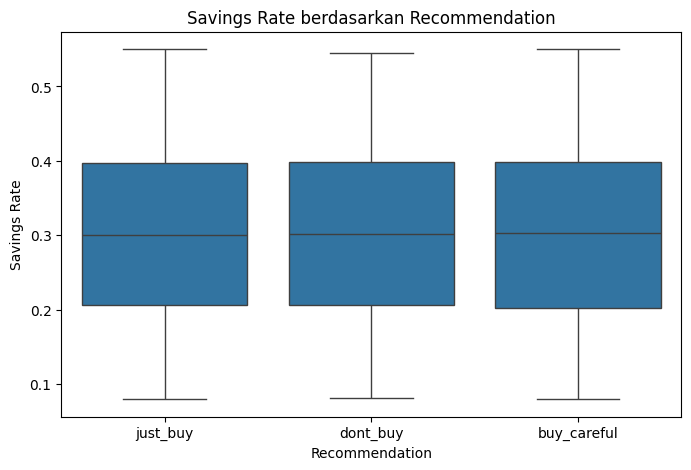

In [29]:
# hubungan savings rate terhadap keputusan pembelian
plt.figure(figsize=(8,5))

sns.boxplot(
    x='label_whatif',
    y='savings_rate',
    data=df_c
)

plt.title('Savings Rate berdasarkan Recommendation')

plt.xlabel('Recommendation')
plt.ylabel('Savings Rate')

plt.show()

### Insight Dataset C
- Sebagian besar pengguna memperoleh rekomendasi paling banyak just_buy yang tentunya juga didasari kondisi finansial mereka.
- Hubungan savings_rate terhadap keputusan pembelian ternyata sama saja hampir tidak ada perbedaan, sehingga gaya belanja (implusif vs hemat), tidak terlalu berpengaruh pada tingkat tabungan seseorang.

## **Mendefinisikan Pertanyaan Bisnis**
### 1. **Business Understanding**

FinTime merupakan platform financial forecasting berbasis machine learning yang membantu pengguna memprediksi kondisi finansial masa depan melalui analisis pengeluaran, simulasi keputusan pembelian, dan visualisasi kondisi keuangan dalam bentuk avatar.



### **2. Pertanyaan Bisnis**
1. Faktor utang atau perilaku apa (antara pinjol_active, credit_card_utilization, impulse_spending_tendency) yang memiliki dampak paling signifikan dalam meningkatkan probabilitas pengguna mendapatkan rekomendasi dont_buy selama 24 bulan ?
2. Apakah terdapat pola musiman pada total pengeluaran (total_expense) dan rasio tabungan (savings_rate) pada bulan-bulan tertentu dalam periode 24 bulan?

## **Explanatory Data Analysis**

### **Pertanyaan 1**

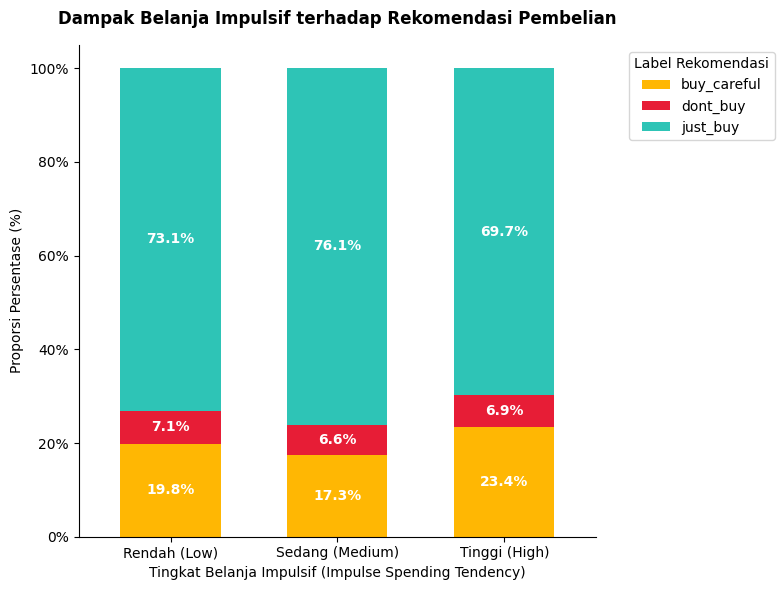

In [30]:
# Menghitung proporsi dan menampilkan stacked bar chart untuk impulse spending tendency
def plot_impulse_spending(df):
    df_cross = pd.crosstab(
        df['impulse_spending_tendency'],
        df['label_whatif'],
        normalize='index'
    ) * 100

    df_cross = df_cross.reindex(['low', 'medium', 'high'])

    fig, ax = plt.subplots(figsize=(8, 6))

    color_map = ['#ffb703', '#e71d36', '#2ec4b6']

    df_cross.plot(kind='bar', stacked=True, color=color_map, ax=ax, width=0.6)

    for p in ax.patches:
        height = p.get_height()
        width = p.get_width()
        x, y = p.get_xy()

        if height > 0:
            ax.text(
                x + width/2,
                y + height/2,
                f'{height:.1f}%',
                ha='center',
                va='center',
                color='white',
                fontweight='bold',
                fontsize=10
            )

    ax.set_title('Dampak Belanja Impulsif terhadap Rekomendasi Pembelian',
                 fontsize=12, pad=15, fontweight='bold')
    ax.set_xlabel('Tingkat Belanja Impulsif (Impulse Spending Tendency)', fontsize=10)
    ax.set_ylabel('Proporsi Persentase (%)', fontsize=10)

    ax.set_xticks(range(len(df_cross)))
    ax.set_xticklabels(['Rendah (Low)', 'Sedang (Medium)', 'Tinggi (High)'], rotation=0)

    ax.set_ylim(0, 105)

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

    ax.legend(title='Label Rekomendasi', bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    plt.tight_layout()
    return fig

fig1 = plot_impulse_spending(df_c)
plt.show()

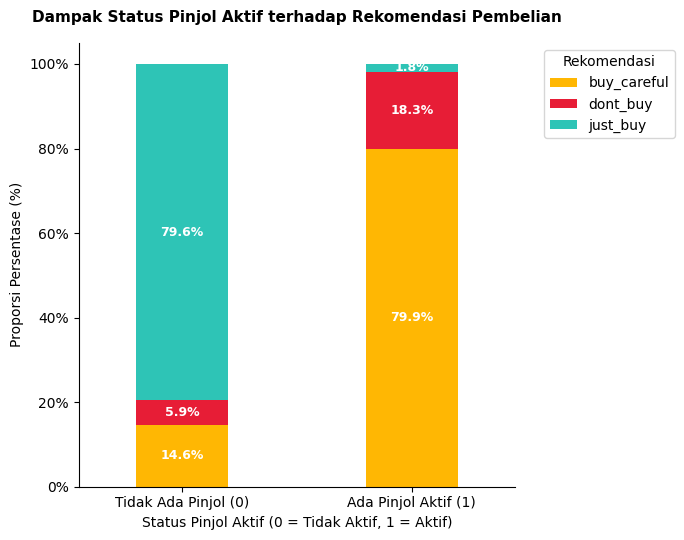

In [31]:
# Menghitung proporsi dan menampilkan stacked bar chart untuk status pinjol
def plot_risk_pinjol(df):
    df_cross = pd.crosstab(df['pinjol_active'], df['label_whatif'], normalize='index') * 100

    fig, ax = plt.subplots(figsize=(7, 5.5))
    color_map = ['#ffb703', '#e71d36', '#2ec4b6']

    df_cross.plot(kind='bar', stacked=True, color=color_map, ax=ax, width=0.4)

    for p in ax.patches:
        height = p.get_height()
        width = p.get_width()
        x, y = p.get_xy()
        if height > 0:
            ax.text(x + width/2, y + height/2, f'{height:.1f}%',
                    ha='center', va='center', color='white', fontweight='bold', fontsize=9)

    ax.set_title('Dampak Status Pinjol Aktif terhadap Rekomendasi Pembelian', fontsize=11, pad=15, fontweight='bold')
    ax.set_xlabel('Status Pinjol Aktif (0 = Tidak Aktif, 1 = Aktif)', fontsize=10)
    ax.set_ylabel('Proporsi Persentase (%)', fontsize=10)

    ax.set_xticks(range(len(df_cross)))
    ax.set_xticklabels(['Tidak Ada Pinjol (0)', 'Ada Pinjol Aktif (1)'], rotation=0)

    ax.set_ylim(0, 105)

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

    ax.legend(title='Rekomendasi', bbox_to_anchor=(1.05, 1), loc='upper left')

    sns.despine()
    plt.tight_layout()
    return fig

fig2 = plot_risk_pinjol(df_c)
plt.show()

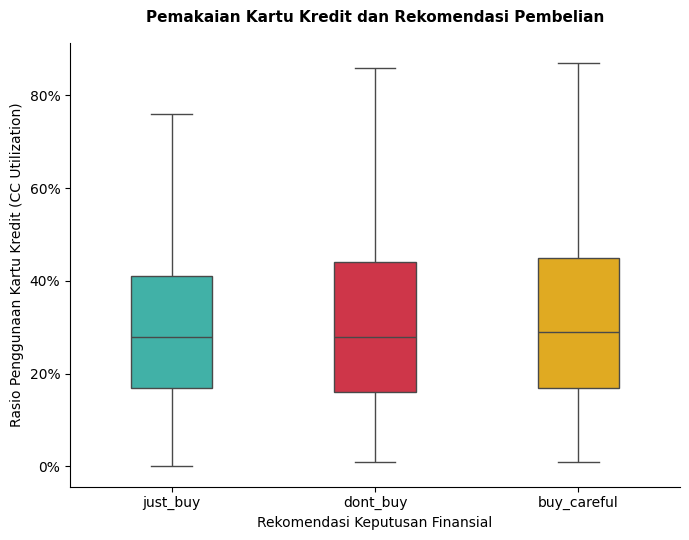

In [32]:
# Menampilkan boxplot untuk credit card utilization
def plot_cc_utilization(df):
    fig, ax = plt.subplots(figsize=(7, 5.5))

    colors = {'just_buy': '#2ec4b6', 'buy_careful': '#ffb703', 'dont_buy': '#e71d36'}

    sns.boxplot(
        data=df,
        x='label_whatif',
        y='credit_card_utilization',
        hue='label_whatif',
        palette=colors,
        legend=False,
        width=0.4,
        ax=ax,
        showfliers=False
    )

    ax.set_title('Pemakaian Kartu Kredit dan Rekomendasi Pembelian', fontsize=11, pad=15, fontweight='bold')
    ax.set_xlabel('Rekomendasi Keputusan Finansial', fontsize=10)
    ax.set_ylabel('Rasio Penggunaan Kartu Kredit (CC Utilization)', fontsize=10)

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

    sns.despine()
    plt.tight_layout()
    return fig

fig3 = plot_cc_utilization(df_c)
plt.show()

### Insight Pertanyaan 1
- Efek dari belanja impulsif terhadap rekomendasi pembelian hampir mirip untuk setiap tingkat impulsivitas (low, medium, high). Rekomendasi pembelian mungkin lebih dipengaruhi oleh faktor-faktor lain.
- Sistem rekomendasi bersifat sangat konservatif terhadap pengguna dengan pinjol aktif, hampir sepenuhnya menghindari rekomendasi just_buy dan lebih sering merekomendasikan buy_careful atau dont_buy. Sebaliknya, pengguna tanpa pinjol justru didominasi rekomendasi just_buy yang menunjukkan adanya perlakuan berbeda berdasarkan status risiko finansial.
- Dari data tersebut terlihat bahwa rekomendasi just_buy diberikan pada rasio penggunaan kartu kredit dari 0% sampai 78%. Sementara itu, rekomendasi dont_buy dan buy_careful sama-sama muncul pada rasio 85%. Hal ini menunjukkan bahwa rasio kartu kredit saja tidak cukup untuk memprediksi rekomendasi, dan ada faktor lain (seperti status pinjol) yang lebih dominan.

### **Pertanyaan 2**

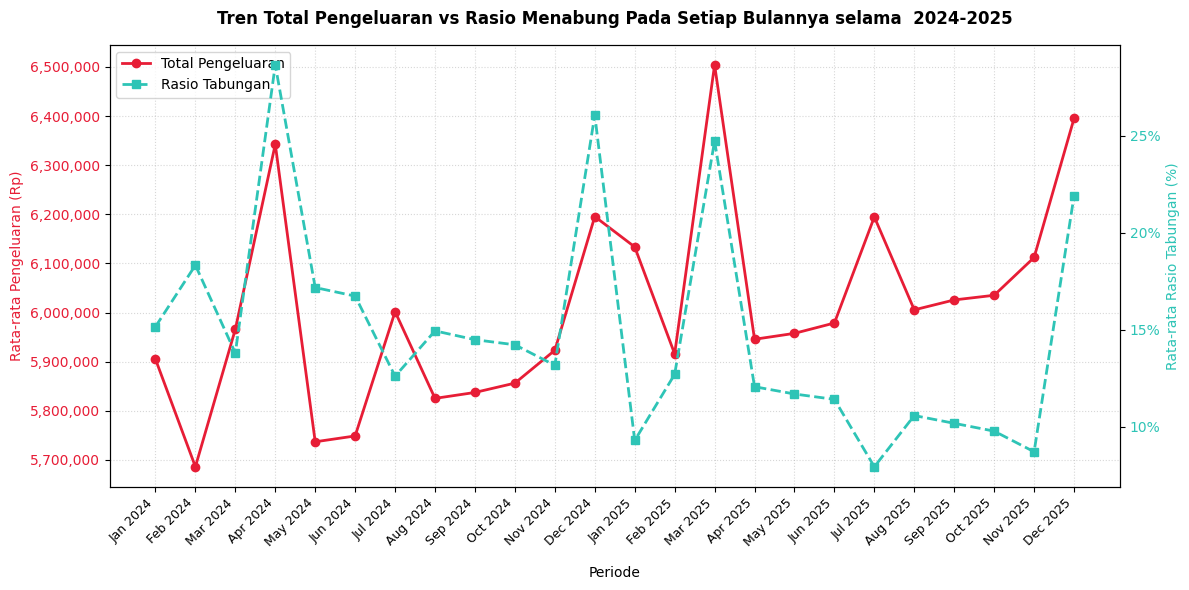

In [33]:
# Visualisasi pengeluaran dan saving rate tiap bulannya untuk melihat pola musiman
def plot_seasonal_trend(df):
    df_seasonal = df.groupby('bulan_index')[['total_expense', 'savings_rate']].mean().reset_index()
    df_seasonal = df_seasonal.sort_values('bulan_index').reset_index(drop=True)

    start_date = "2024-01-01"
    month_labels = pd.date_range(start=start_date, periods=len(df_seasonal), freq='ME').strftime('%b %Y')

    fig, ax1 = plt.subplots(figsize=(12, 6))

    color_expense = '#e71d36'
    ax1.set_xlabel('Periode', fontsize=10, labelpad=12)
    ax1.set_ylabel('Rata-rata Pengeluaran (Rp)', color=color_expense, fontsize=10)

    line1 = ax1.plot(
        df_seasonal['bulan_index'], df_seasonal['total_expense'],
        color=color_expense, marker='o', linewidth=2, label='Total Pengeluaran'
    )
    ax1.tick_params(axis='y', labelcolor=color_expense)
    ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))

    ax2 = ax1.twinx()
    color_savings = '#2ec4b6'
    ax2.set_ylabel('Rata-rata Rasio Tabungan (%)', color=color_savings, fontsize=10)

    line2 = ax2.plot(
        df_seasonal['bulan_index'], df_seasonal['savings_rate'],
        color=color_savings, marker='s', linestyle='--', linewidth=2, label='Rasio Tabungan'
    )
    ax2.tick_params(axis='y', labelcolor=color_savings)
    ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))

    ax1.set_xticks(df_seasonal['bulan_index'])
    ax1.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=9)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')

    ax1.set_title('Tren Total Pengeluaran vs Rasio Menabung Pada Setiap Bulannya selama  2024-2025',
                 fontsize=12, pad=15, fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    return fig

fig4 = plot_seasonal_trend(df_b)
plt.show()

### Insight Pertanyaan 2
- Terjadi lonjakan pengeluaran tahunan yang sangat tinggi pada bulan-bulan tertentu, yaitu di sekitar Maret - April dan Desember baik di tahun 2024 maupun 2025.
- Sifat pengeluaran pengguna sangat dipengaruhi oleh siklus musiman tahunan. Lonjakan di bulan Maret-April sangat berkorelasi dengan periode Ramadhan dan Idul Fitri (seperti mudik/lebaran), sedangkan lonjakan di bulan Desember dipicu oleh libur akhir tahun, Natal, dan Tahun Baru.
- Tren pengeluaran juga menunjukkan pola kenaikan konsisten setiap bulan Juli. Hal ini bisa terjadi karena siklus tahun ajaran baru, di mana pengguna harus mengalokasikan dana ekstra untuk kebutuhan pendidikan (uang sekolah, seragam, dan perlengkapan akademik), yang juga berdampak pada penurunan kapasitas menabung.